# PROBLEM STATEMENT

## To Predict the Future price/Fare of the Fight

In [1]:
#Importing basic libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
#loading the data
df =pd.read_excel('Flight_Fare.xlsx')
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


## Basic Checks

In [3]:
# Basic check of the dataset
df.head()  # what features are here and head columns

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail() # checking end of data how many rows present

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.info() # checking the data information like 
# how many rows and columns present
# Any missing values and the Datatyes of the column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.describe() # statistical presentation min,max,mean,count,std

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
df.describe(include=['object']) # statistical presentation of categorical data
# Maximum data is present in object type.

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


In [8]:
df.isnull().sum() # checking the null in which column
# Route and Total_Stops present one null value in both

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.duplicated().sum() # Checking Duplicate values
# Here some duplicate values is present

np.int64(220)

In [10]:
df.shape # The shape of the data

(10683, 11)

# Domain Anlaysis

1. Airline: This column will have all the types of airlines like Indigo, Jet Airways,Air India,..etc and also this column are categorical types values.
2. Date_of_Journey: This column will let us know about the date on which the passenger’s journey will start.
3. Source: This column holds the name of the place from where the passenger’s journey will start.
4. Destination: This column holds the name of the place to where passengers wanted to travel.
5. Route: Here we can know about what the route is through which passengers have opted to travel from his/her source to their destination.
6. Dep_Time: The time at which an activity starts for flight takeoff.
6. Arrival_Time: Arrival time is when the passenger will reach his/her destination.
7. Duration: Duration is the whole period that a flight will take to complete its journey from source to destination.
8. Total_Stops: This will let us know in how many places flights will stop there forthe flight in the whole journey.
9. Additional_Info: In this column, we will get information about food, kind of food,and other amenities.
10. Price: Price of the flight for a complete journey including all the expenses before onboarding.

# EDA

## Univariant Analysis

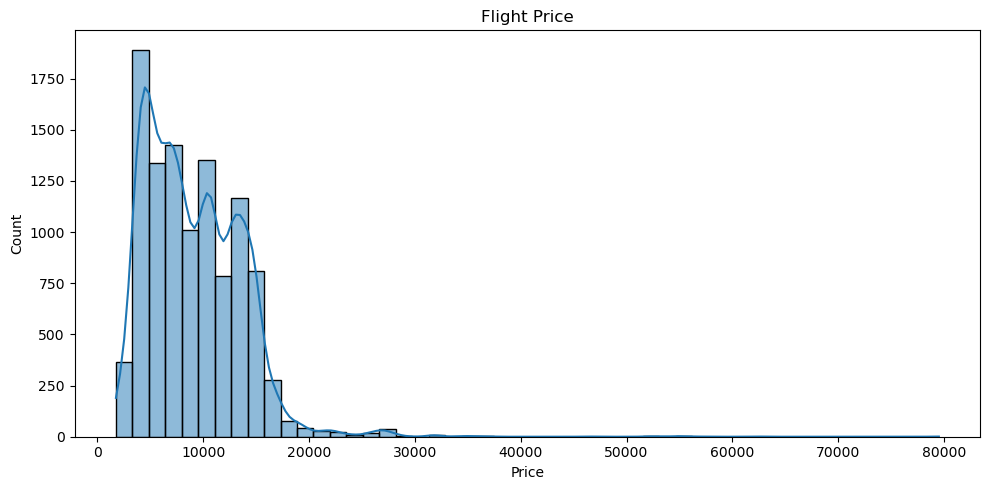

In [11]:
# Graph for price
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Price', kde=True, bins=50)
plt.title('Flight Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

* Flight price is right-skewed and the maximum ticket price between 4000 to 12000.
* The average price of Fight ticket is 9000.
* There are so Outliers present in the price near to 80,000.

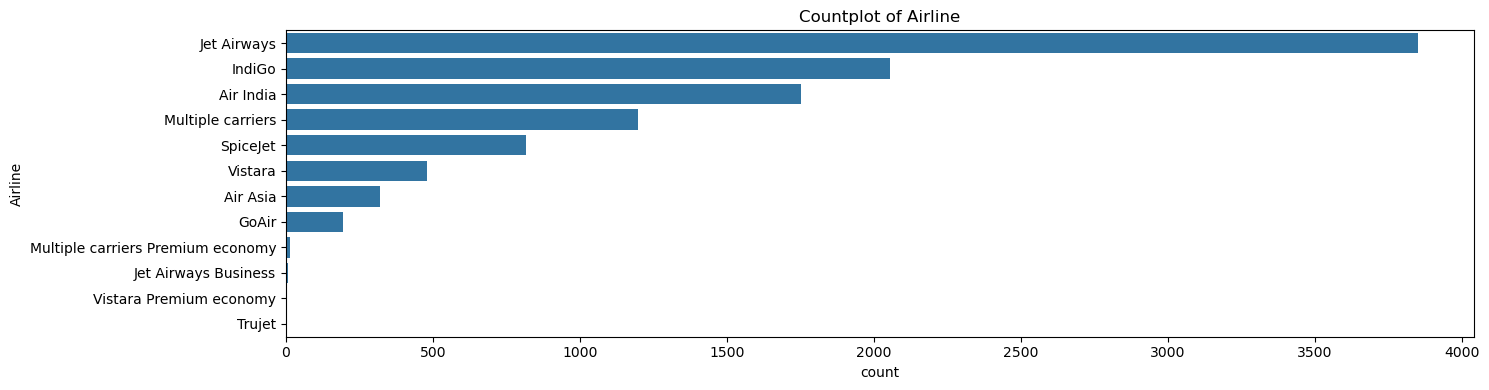

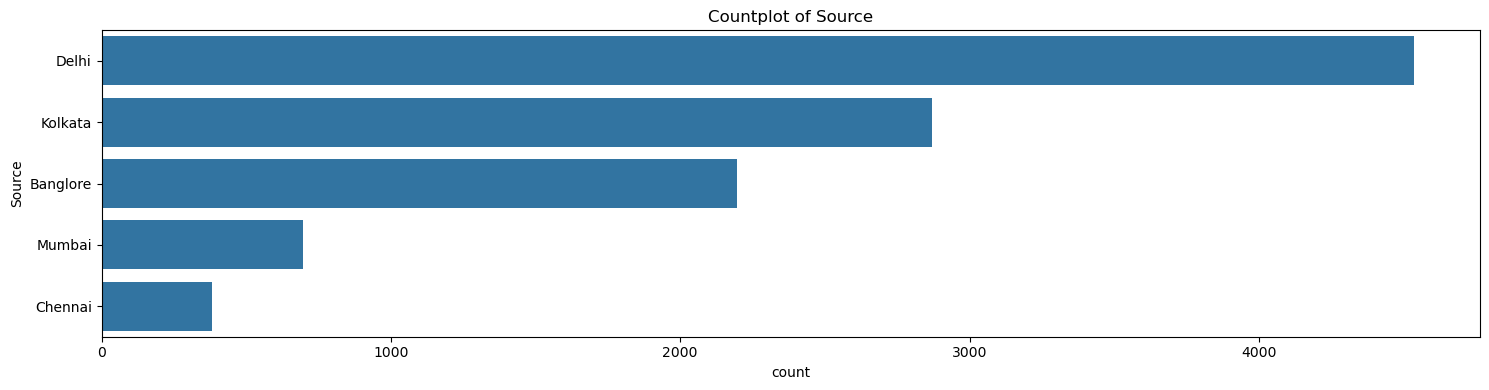

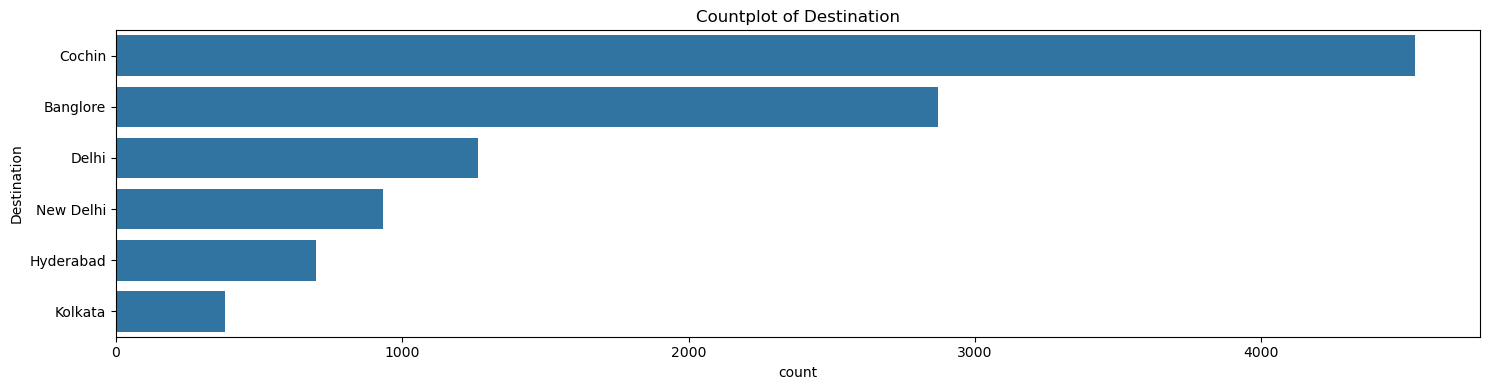

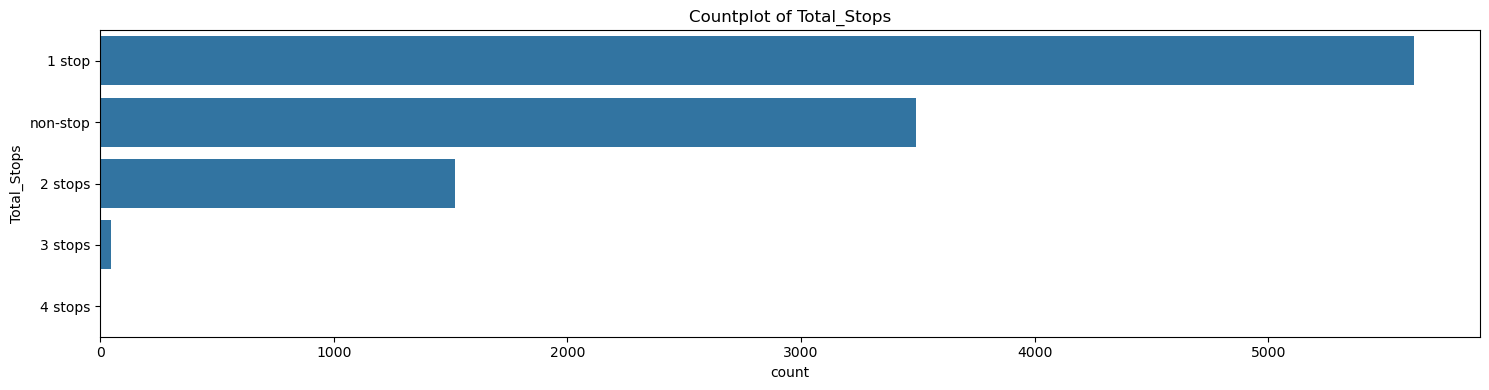

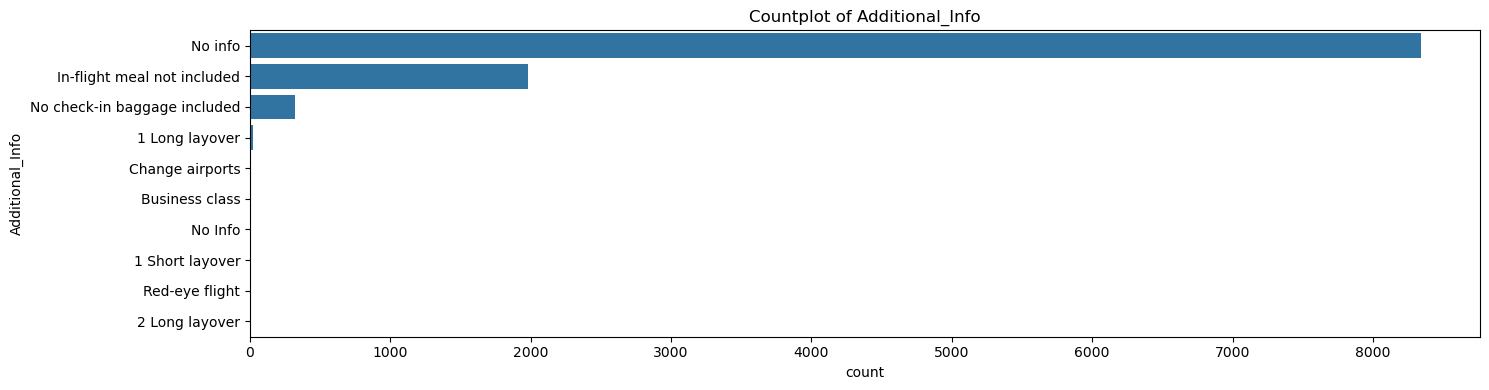

In [12]:
# Graph for Categorical data 
df_cat = ['Airline','Source','Destination','Total_Stops', 'Additional_Info'] 

for col in df_cat:
    plt.figure(figsize=(15,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.xticks(rotation=0)
    plt.title(f"Countplot of {col}")
    plt.tight_layout()
    plt.show()



* Jet Airways is at top many choose to travel after that Indigo and Air India.
* Delhi ana Cochin are very frequently places travelled.
* 1 Stop is most common and second one is non-stop.
* In AdditionInfo 80% of the data is "no info" present we can drop the feature/column

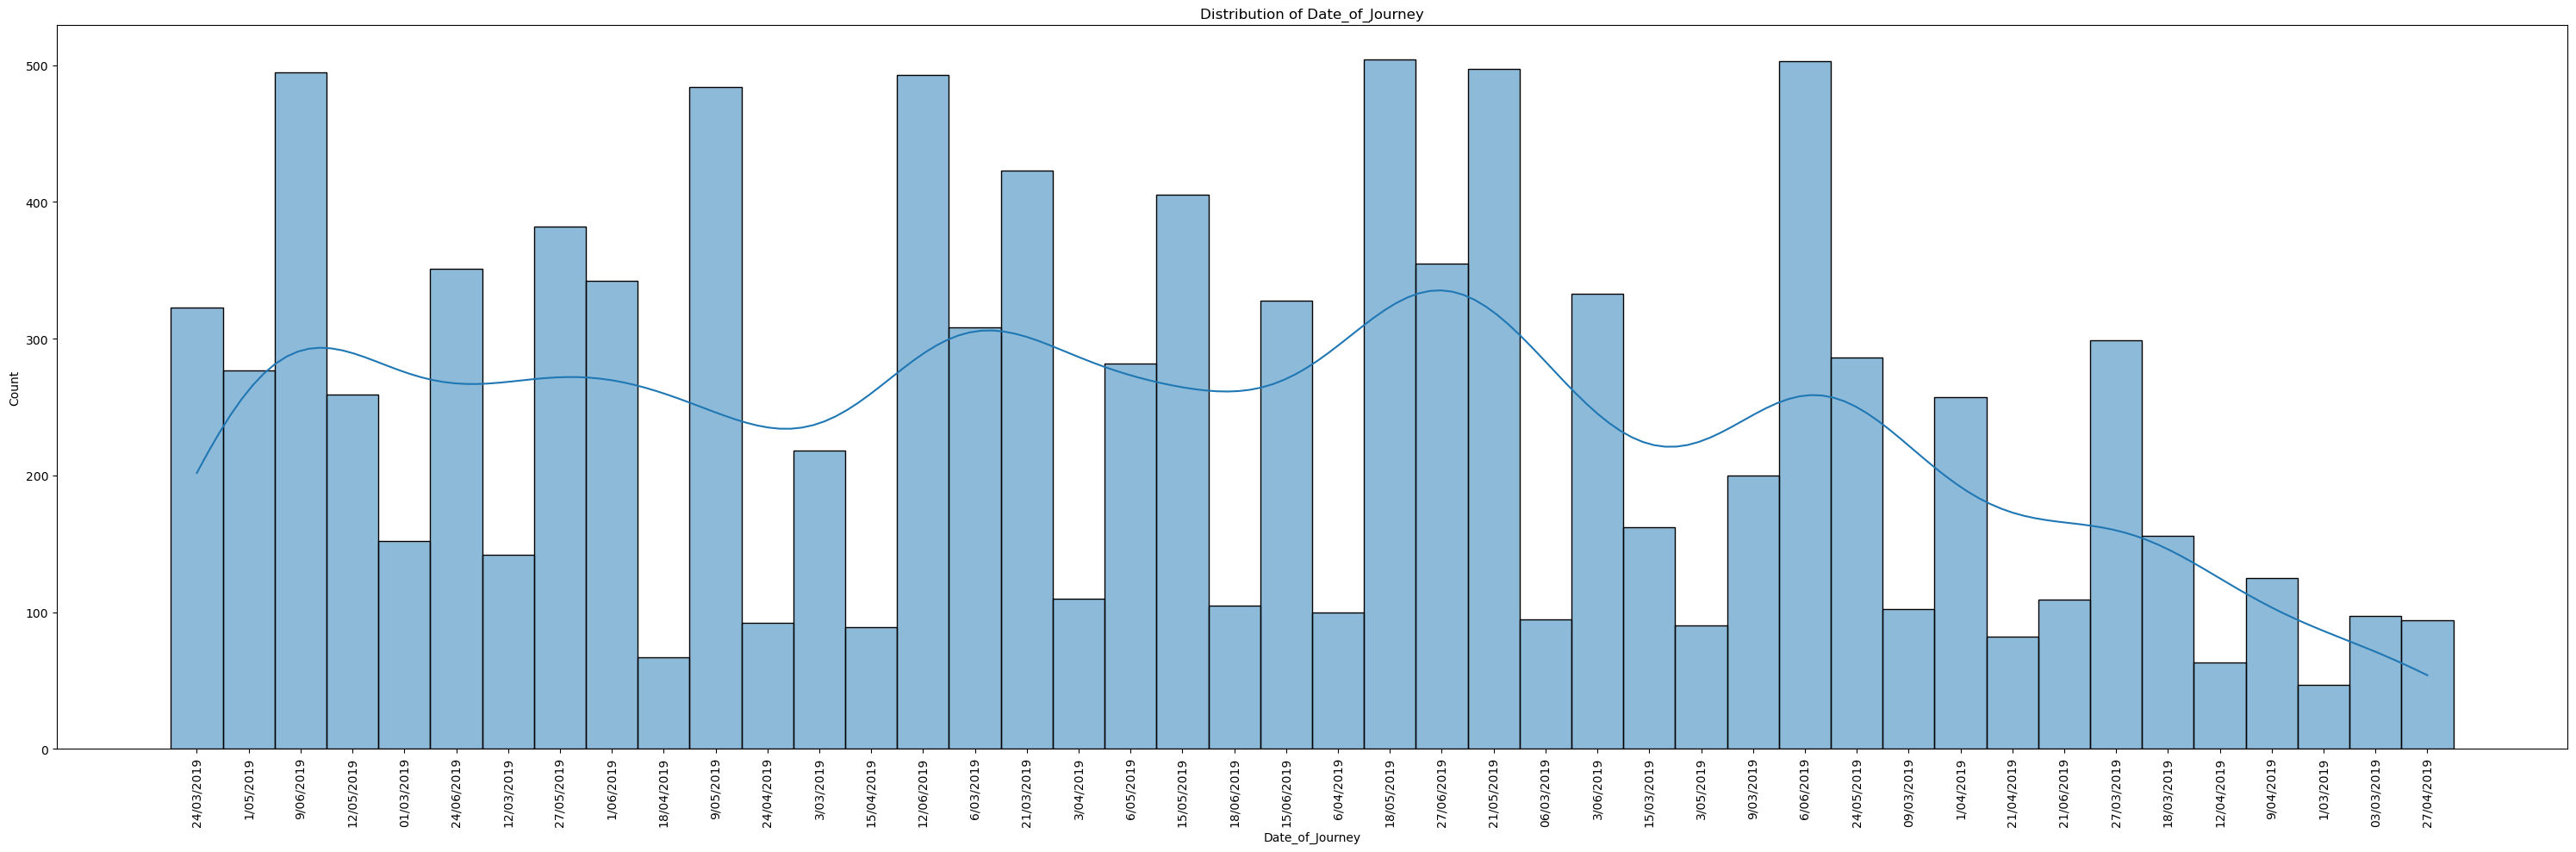

In [13]:
# Graph for Date of journey 
df_date = ['Date_of_Journey']

for col in df_date:
    plt.figure(figsize=(30,10))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


* The data is present between March to june of 2019.
* on 18-05-2019 max travel happened oh

## Bi-Variant Analysis

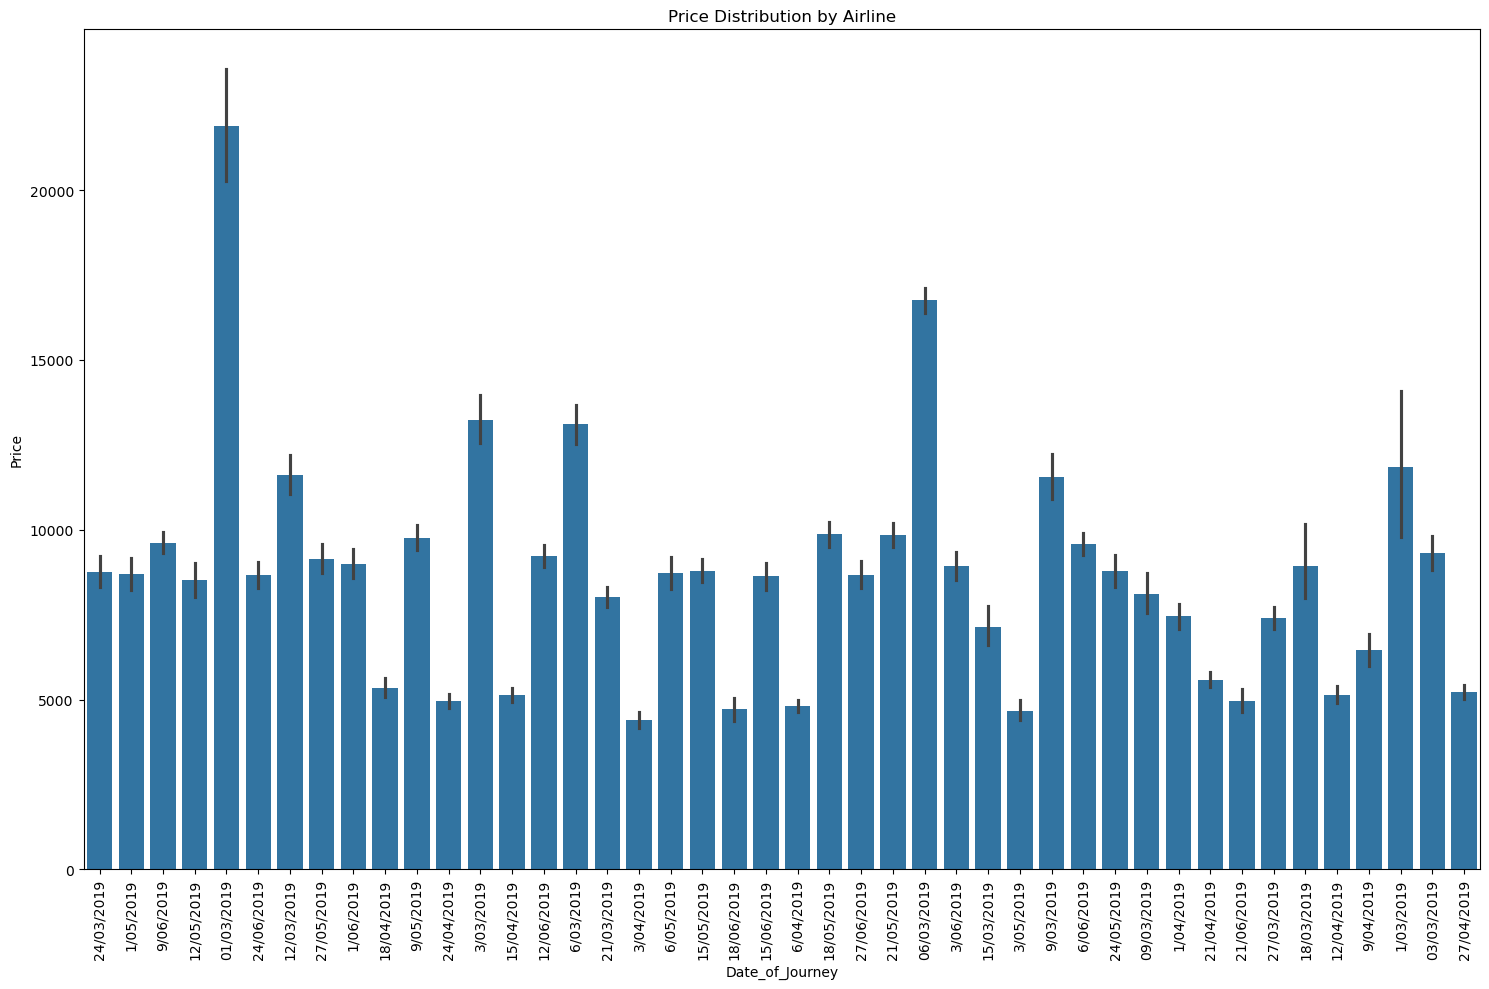

In [14]:
plt.figure(figsize=(15,10))
sns.barplot(x='Date_of_Journey', y='Price', data=df)
plt.title('Price Distribution by Airline')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 6))
sns.barplot(x='Total_Stops', y='Price', data=df)
plt.title('Price Distribution by Airline')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df.head(2)

# Data Preprocessing

In [ ]:
df.isnull().sum()

In [ ]:
df_pre = df.copy()

In [ ]:
df_pre.isnull().sum()

In [ ]:
df_pre[df_pre["Route"].isnull()]

In [ ]:
df_mode = df_pre['Route'].mode()[0]
df_pre['Route'].fillna(df_mode, inplace=True)

In [ ]:
mode_df = df_pre['Total_Stops'].mode()[0]
df_pre['Total_Stops'].fillna(mode_df, inplace=True)

In [ ]:
df_pre.isnull().sum()

In [ ]:
df_pre.duplicated().sum()

In [ ]:
df_pre.drop_duplicates(inplace=True)


In [ ]:
df_pre.duplicated().sum()

In [ ]:
df_pre.shape

In [ ]:
df_pre.head()

## Droping the columns
* Drop the 'Route' and AdditionalInfo columns
* Route is relation to Total_Stops so we drop Route
* AdditionINfo contain 80% of data with "No info" we drop AdditionInfo

In [ ]:
df_pre.drop(columns = 'Route', inplace = True)  # drop -- Route
df_pre.drop(columns = 'Additional_Info', inplace = True) # drop Additional_Info

In [ ]:
df_pre.head()

In [ ]:
print(df_pre.columns)

In [ ]:
# Convert Date_of_Journey column to datetime and show only the day
df_pre["Journey_day"] = pd.to_datetime(df_pre.Date_of_Journey, format="%d/%m/%Y").dt.day

In [ ]:
# Extract month from Date_of_Journey
df_pre["Journey_month"] = pd.to_datetime(df_pre["Date_of_Journey"], format = "%d/%m/%Y").dt.month

In [ ]:
# Now we will drop date of journey
df_pre.drop(["Date_of_Journey"], axis = 1, inplace = True)

In [ ]:
df_pre.head()

In [ ]:
# Extract hour from Dep_Time and create a new column
df_pre["Dep_hour"] = pd.to_datetime(df_pre["Dep_Time"]).dt.hour

In [ ]:
df_pre["Dep_min"] = pd.to_datetime(df_pre["Dep_Time"]).dt.minute

In [ ]:
df_pre.drop(["Dep_Time"], axis = 1, inplace = True)

In [ ]:
df_pre.head()

In [ ]:
# Extract hour from Arrival_Time and create a new column
df_pre["Arrival_time"] = pd.to_datetime(df_pre.Arrival_Time).dt.hour

In [ ]:
df_pre["Arrival_min"] = pd.to_datetime(df_pre.Arrival_Time).dt.minute

In [ ]:
df_pre.drop(["Arrival_Time"], axis = 1, inplace = True)

In [ ]:
df_pre.head()

In [ ]:
#-Checks each value in the Duration column.
# If "h" is not present (meaning only minutes are given, e.g. "30m"), it adds "0h " at the start.
# Example: "30m" → "0h 30m".

#-Checks each value again.
#If "m" is not present (meaning only hours are given, e.g. "2h"), it adds "0m" at the end.
#Example: "2h" → "2h 0m".

#-Uses regex (\d+)h to find digits before "h".
#Example: "2h 50m" → 2.
#Converts the result into integers.
#Creates a new column Duration_hours.

#-Uses regex (\d+)m to find digits before "m".
#Example: "2h 50m" → 50.
#Converts the result into integers.
#Creates a new column Duration_mins


df_pre["Duration"] = df_pre["Duration"].str.replace("h", "h ").str.strip()
df_pre["Duration"] = df_pre["Duration"].apply(lambda x: x if "h" in x else "0h " + x)
df_pre["Duration"] = df_pre["Duration"].apply(lambda x: x if "m" in x else x + " 0m")

# Extract hours and minutes directly
df_pre["Duration_hours"] = df_pre["Duration"].str.extract(r'(\d+)h').astype(int)
df_pre["Duration_mins"]  = df_pre["Duration"].str.extract(r'(\d+)m').astype(int)

In [ ]:
# Show first 10 rows seperate duration_hours and duration_min
print(df_pre[["Duration", "Duration_hours", "Duration_mins"]].head(20))

In [ ]:
df_pre.drop(['Duration'],axis = 1,inplace = True)

In [ ]:
df_pre.head()

In [ ]:
print(df_pre.columns)

In [ ]:
df_pre.info()

In [ ]:
num_col = ['Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_min', 'Arrival_time', 'Arrival_min', 'Duration_hours','Duration_mins']

In [ ]:
for col in num_col:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df_pre[col])
  plt.show()

In [ ]:
# Airline vs Price using catplot
sns.catplot(
    x="Airline", 
    y="Price", 
    data=df_pre, 
    kind="boxen",        # boxplot shows median, quartiles, and outliers
    height=6, 
    aspect=2, 
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Airline vs Price Distribution")
plt.show()

In [ ]:
sns.catplot(
    x="Source", 
    y="Price", 
    data=df_pre, 
    kind="boxen",        # boxplot shows median, quartiles, and outliers
    height=6, 
    aspect=2, 
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Source vs Price Distribution")
plt.show()

# INSIGHTS

1)Jet Airways Business & Multiple Carriers Premium Economy

These categories have much higher price ranges (peaks around ₹60,000–₹80,000).

They are rare in count but dominate the upper end of fares.

Outliers are visible, showing extreme ticket prices.

2)Jet Airways (Economy)

Has a broad distribution, overlapping with both budget and premium ranges.

This explains why Jet Airways dominates in count and price variability.

3)Rare Airlines (TruJet, Premium categories)

Very few entries, but their prices are either extremely low (TruJet) or extremely high (premium classes).

These categories may add noise to models if left as-is.

4)Delhi dominates in both flight count and price variability, making it the most complex source city for fare prediction.

5)Bangalore and Kolkata show balanced distributions, useful for stable modeling.

6)Chennai and Mumbai lean toward budget fares, with fewer premium options.

7)Outliers in Delhi and Bangalore highlight the presence of premium or multi-stop flights that significantly raise prices.

# Feature Engineering

## One-Hot Encoding

In [ ]:
df_pre["Airline"].value_counts()

In [ ]:
Airline = pd.get_dummies(df["Airline"], drop_first=True, dtype=int)
Airline.head()


In [ ]:
df_pre["Source"].value_counts()

In [ ]:
Source = df[["Source"]]

Source = pd.get_dummies(Source, drop_first= True,dtype=int)

Source.head()

In [ ]:
df_pre["Destination"].value_counts()

In [ ]:
Destination = df[["Destination"]]

Destination = pd.get_dummies(Destination, drop_first = True,dtype=int)

Destination.head()

In [ ]:
df_pre["Total_Stops"].value_counts()

In [ ]:
df_pre.replace({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}, inplace = True)

In [ ]:
df_pre.head()

In [ ]:
df_pre = pd.concat([df_pre, Airline, Source, Destination], axis = 1)

In [ ]:
df_pre.head()

In [ ]:
df_pre.drop(columns=['Airline', 'Source', 'Destination'], inplace=True)

In [ ]:
df_pre.head()

In [ ]:
final_df = df_pre.copy()
final_df.isnull().sum()

In [ ]:
# If any NaNs persist in final_df
final_df.fillna(method='ffill', inplace=True)
# Or column-specific: final_df['TotalStops'].fillna(final_df['TotalStops'].mode()[0], inplace=True)


In [ ]:
final_df.isnull().sum()

In [ ]:
final_df.duplicated().sum()

In [ ]:
final_df.drop_duplicates(inplace=True)

In [ ]:
final_df.duplicated().sum()

# Model Building

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import math

In [ ]:
# we Seperate the features and target 
X = final_df.drop('Price',axis=1)
y = final_df['Price']

In [ ]:
# Spliting the data for Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scaling

In [ ]:
# After splitting
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression

In [ ]:
# Creating the model
LR = LinearRegression() # object creation
model = LR.fit(X_train_scaled,y_train) # training of linear regression
model

In [ ]:
y_pred_LR= LR.predict(X_test_scaled)

In [ ]:
y_pred_LR

In [ ]:
y_test

In [ ]:
# Model Evalution
print("MSE: ",mean_squared_error(y_test,y_pred_LR))
print("MAE: ",mean_absolute_error(y_test,y_pred_LR))
print("RMSE: ",math.sqrt(mean_squared_error(y_test,y_pred_LR)))

In [ ]:
# R2
r2score = r2_score(y_test,y_pred_LR)
r2score

# KNN Model

In [ ]:
# Using KNN model
from sklearn.neighbors import KNeighborsRegressor

#  Create and train the KNN regressor
k = 5 
knn_model = KNeighborsRegressor(n_neighbors=k)
knn_model.fit(X_train_scaled, y_train)  # Train the model

In [ ]:
# Make predictions on test data
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
y_pred_knn

In [ ]:
y_test

In [ ]:
# Step 7: Evaluate the model
mse = mean_squared_error(y_test, y_pred_knn)
print(f"Mean Squared Error: {mse:.4f}")

In [ ]:
# Root Mean Squared Error (RMSE) - Lower is better
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.4f}")

In [ ]:
# Mean Absolute Error (MAE) - Lower is better
mae = mean_absolute_error(y_test, y_pred_knn)
print(f"Mean Absolute Error: {mae:.4f}")

In [ ]:
# R-squared (coefficient of determination) - Higher is better (max is 1.0)
r2 = r2_score(y_test, y_pred_knn)
print(f"R² Score: {r2:.4f}")

# Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Using Random forest model
rf_reg_model = RandomForestRegressor() 
rf_reg_model.fit(X_train_scaled, y_train)

In [ ]:
y_pred_rf= rf_reg_model.predict(X_test_scaled) # Predict the data

In [ ]:
y_pred_rf

In [ ]:
y_test

In [ ]:
# Evaluate the model 
mse = mean_squared_error(y_test, y_pred_rf) 
rmse = np.sqrt(mse) 
print("MSE:",mse)
print("RMSE:", rmse)

In [ ]:
# Normal R² 
r2 = r2_score(y_test, y_pred_rf)
print("R²:", r2) 


In [ ]:
# Adjusted R² 
n = X_test.shape[0] # number of observations 
p = X_test.shape[1] # number of predictors 
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) 

print("Adjusted R²:", adj_r2)

# XG Boost

In [ ]:
from xgboost import XGBRegressor

# Using XG Boost Model
xgb = XGBRegressor()
xgb.fit(X_train_scaled, y_train)

In [ ]:
y_pred_xg = xgb.predict(X_test_scaled)

In [ ]:
y_pred_xg

In [ ]:
y_test

In [ ]:
r2 = r2_score(y_test, y_pred_xg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xg))

In [ ]:
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

# GB Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Using Gradient Boost Model
gb = GradientBoostingRegressor()
gb.fit(X_train_scaled, y_train)

In [ ]:
y_pred_gb = gb.predict(X_test_scaled)

In [ ]:
y_pred_gb

In [ ]:
y_test

In [ ]:
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

In [ ]:
print(f"Gradient Boosting - R² Score: {r2_gb:.4f}")
print(f"Gradient Boosting - RMSE: {rmse_gb:.2f}")

# Hyperparameter Tuning on XG Boost Model

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}


In [ ]:
xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV( xgb, param_grid, cv=3, 
    scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
                          )
grid_search.fit(X_train_scaled, y_train)


In [ ]:
print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

In [ ]:
# Predictions and evaluation
y_pred_tuned = best_model.predict(X_test_scaled)
r2_tuned = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

In [ ]:
print(f"Tuned R²: {r2_tuned:.4f}")
print(f"Tuned RMSE: {rmse_tuned:.2f}")

# RandomSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}



In [ ]:
xgb = XGBRegressor(random_state=42)
random_search = RandomizedSearchCV(
    xgb, param_distributions=param_dist, 
    n_iter=50,  # Number of random combinations
    cv=3, 
    scoring='neg_mean_squared_error',
    n_jobs=-1, 
    random_state=42,
    verbose=1
)
random_search.fit(X_train_scaled, y_train)


In [ ]:
print("Best parameters:", random_search.best_params_)
best_model_rs = random_search.best_estimator_

In [ ]:
# Predictions and evaluation
y_pred_rs = best_model_rs.predict(X_test_scaled)
r2_rs = r2_score(y_test, y_pred_rs)
rmse_rs = np.sqrt(mean_squared_error(y_test, y_pred_rs))

In [ ]:
print(f"RandomSearchCV R²: {r2_rs:.4f}")
print(f"RandomSearchCV RMSE: {rmse_rs:.2f}")

# Model Comparison Report

1. Data Context
Dataset size: 10,683 rows, 11 columns

Target: Flight Price (continuous, right‑skewed with outliers)

Features: Mostly categorical (Airline, Route, Source, Destination, Total_Stops) plus engineered time features (Dep_hour, Arr_hour, Duration_minutes).

Challenges: High‑cardinality categoricals, skewed target distribution, duplicates, mixed duration formats.

2. Models Evaluated
1) K-Nearest Neighbors (KNN)
Concept: Predicts price by averaging prices of the k most similar flights.

Strengths: Simple, non‑parametric, intuitive.

Weaknesses:

Sensitive to scaling and irrelevant features.

Struggles with categorical encodings and high dimensionality.

Slow inference in production.

2) Random Forest
Concept: Ensemble of decision trees using bagging.

Strengths:

Robust to outliers and skewed distributions.

Handles categorical encodings well.

Provides feature importance for interpretability.

Weaknesses:

Larger model size → slower inference than boosting.

Less accurate than boosting methods on complex tabular data.

3) Gradient Boosting (GBM)
Concept: Sequentially builds trees, each correcting errors of the previous.

Strengths:

Handles skewed targets better than Random Forest.

Captures nonlinear interactions effectively.

Weaknesses:

Slower training compared to XGBoost

Sensitive to hyperparameters (learning rate, depth).

4) XGBoost (with RandomizedSearchCV tuning)
Concept: Optimized gradient boosting with regularization and efficient training.

Strengths:

Excellent performance on tabular data.

Robust to skewed targets and categorical interactions.

Efficient training with early stopping and regularization.

Weaknesses: Requires careful hyperparameter tuning.

Your Result: After hyperparameter tuning with RandomizedSearchCV, achieved R² = 0.8510 → strong predictive power.

# Report on Challenges faced
1) Challenges Faced in the Data
 High Cardinality Categorical Features

Columns like Airline, Route, and Additional_Info had many unique values.

Challenge: One-hot encoding would explode feature space and cause sparsity.

2) Duration Format Inconsistency

Duration column had mixed formats (2h 50m, 5h, 30m).

Challenge: Hard to use directly for modeling; needed normalization.

3) Time Features Embedded in Strings

Dep_Time and Arrival_Time were string timestamps.

Challenge: Couldn’t capture temporal patterns without extraction.

4) Duplicate Records

220 duplicate rows detected.

Challenge: Risk of biasing model training and inflating performance metrics.

5) Missing Values

1 null in Route, 1 null in Total_Stops.

Challenge: Small but needed consistent handling.

6) Skewed Target Distribution

Price was right-skewed with extreme outliers (up to ~80,000).

Challenge: Models sensitive to outliers could mispredict typical ranges.

2. Techniques Used & Reasons
 Data Cleaning

Duplicates removed → Prevented bias and ensured fair training.

Null imputation → Filled missing Route and Total_Stops with mode values for consistency.

7) Feature Engineering

Duration converted to minutes → Standardized numeric representation.

Time extraction → Derived Dep_hour, Arr_hour, Day_of_week, Month for temporal trends.

Stops encoding → Converted Total_Stops into integer values for direct modeling.

8) Encoding

Frequency/Target encoding for high-cardinality (Route, Additional_Info) → Reduced dimensionality while preserving signal.

One-hot encoding for low-cardinality (Source, Destination, Airline) → Allowed tree models to split effectively.

9) Outlier Handling

Winsorization (top 1–2%) → Reduced extreme influence on regression models.

Tree-based models inherently robust → Outliers less impactful compared to linear regression.

10) Model Selection

Random Forest → Strong baseline, interpretable feature importance.

XGBoost → Best performance on skewed tabular data, efficient with categorical encodings.

11) Evaluation

Used RMSE (penalizes large errors) and MAE (robust to outliers).

Stratified train-test split by price deciles → Preserved distribution across sets.

12). Key Insights
Tree-based gradient boosting (XGBoost) consistently outperformed linear models due to nonlinear interactions between airline, route, and time features.

Feature engineering (duration normalization, time extraction) significantly improved predictive power.

Encoding strategy was critical: naive one-hot encoding would have led to sparse, inefficient models.